<div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 40px; margin-top: 0;">
    <div style="flex: 0 0 auto; margin-left: 0; margin-bottom: 0; margin-top: 0;">
        <img src="./pics/UCSD Logo.png" alt="UCSD Logo" style="width: 179px; margin-bottom: 0px; margin-top: 20px;">
    </div>
    <div style="flex: 0 0 auto; margin-left: auto; margin-bottom: 0; margin-top: 20px;">
        <img src="./pics/sdsc-logo.png" alt="SDSC Logo" style="width: 300px; margin-bottom: 0px;">
    </div>
    <div style="flex: 0 0 auto; margin-left: auto; margin-bottom: 0; margin-top: 20px;">
        <img src="./pics/usda-logo.png" alt="USGS Logo" style="width: 100px; margin-bottom: 0px;">
    </div>
    <div style="flex: 0 0 auto; margin-left: auto; margin-bottom: 0; margin-top: 20px;">
        <img src="./pics/wstc-logo.png" alt="WSTC Logo" style="width: 100px; height: 100px; margin-bottom: 0px;">
    </div>
</div>

<h1 style="text-align: center; font-size: 48px; margin-top: 0;">National Agriculture Imagery Program (NAIP)</h1>

- **Team Name:** Dry shRub  
- **Team Members:**
    - Uzair Gheewala
    - Sean Harmon

1. In the `NAIP.ipynb` notebook, we defined a small bounding box within Independence Lake.

For this Data Challenge, you will work with data located at [D. L. Bliss State Park](https://en.wikipedia.org/wiki/D._L._Bliss_State_Park), one of our areas of interest (AOI). Select a NAIP image whose footprint intersects D. L. Bliss.

Use the following bounding box (WGS84 lon/lat) as a reference:

* Min X (lon): -120.1018846
* Min Y (lat): 38.99274873
* Max X (lon): -120.0899834
* Max Y (lat): 39.0020357

**NOTE:** You might get multiple images. Keep only one for the purpose of the following tasks.

In [3]:
%pip install -r requirements.txt

  Using cached geoai_py-0.35.0-py2.py3-none-any.whl.metadata (12 kB)
Using cached geoai_py-0.35.0-py2.py3-none-any.whl (565 kB)
Note: you may need to restart the kernel to use updated packages.


In [4]:
from geoai.download import (
    download_naip,
    download_overture_buildings,
    extract_building_stats,
)
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import rasterio
from pyproj import Transformer
from shapely.geometry import box
import rasterio.windows
from rasterio.windows import Window
from rasterio.transform import xy

In [29]:
bbox_wgs84 = (-120.1018846, 38.99274873, -120.0899834, 39.0020357)

downloaded_files = download_naip(
    bbox=bbox_wgs84,
    output_dir="task_naip_data",
    max_items=2
)

Found 2 NAIP items.


m_3912064_sw_10_060_20220721.tif: 100%|██████████| 207M/207M [00:41<00:00, 5.22MiB/s] 


Successfully saved to task_naip_data/m_3912064_sw_10_060_20220721.tif


m_3812008_nw_10_060_20220721.tif: 100%|██████████| 355M/355M [01:16<00:00, 4.85MiB/s] 

Successfully saved to task_naip_data/m_3812008_nw_10_060_20220721.tif


2. Using the DL Bliss image, inspect the general info and compare it with the Independence Lake image.

In [31]:
ind_lake_path = "./naip_data/m_3912038_ne_10_060_20220720.tif"

with rasterio.open(ind_lake_path) as src:
    print("File:", ind_lake_path)
    print("CRS:", src.crs)
    print("Size (WxH):", src.width, "x", src.height)
    print("Count (bands):", src.count)
    print("Dtypes:", src.dtypes)
    print("Nodata:", src.nodata)
    print("Bounds:", src.bounds)
    print("Transform:\n", src.transform)
    print("Res (pixel size):", src.res)

File: ./naip_data/m_3912038_ne_10_060_20220720.tif
CRS: EPSG:26910
Size (WxH): 9980 x 12500
Count (bands): 4
Dtypes: ('uint8', 'uint8', 'uint8', 'uint8')
Nodata: None
Bounds: BoundingBox(left=730884.0, bottom=4368576.0, right=736872.0, top=4376076.0)
Transform:
 | 0.60, 0.00, 730884.00|
| 0.00,-0.60, 4376076.00|
| 0.00, 0.00, 1.00|
Res (pixel size): (0.6, 0.6)


In [35]:
dl_bliss_fp = Path("task_naip_data") / "m_3812008_nw_10_060_20220721.tif"

with rasterio.open(dl_bliss_fp) as src:
    print("File:", dl_bliss_fp)
    print("CRS:", src.crs)
    print("Size (WxH):", src.width, "x", src.height)
    print("Count (bands):", src.count)
    print("Dtypes:", src.dtypes)
    print("Nodata:", src.nodata)
    print("Bounds:", src.bounds)
    print("Transform:\n", src.transform)
    print("Res (pixel size):", src.res)

File: task_naip_data/m_3812008_nw_10_060_20220721.tif
CRS: EPSG:26910
Size (WxH): 10070 x 12530
Count (bands): 4
Dtypes: ('uint8', 'uint8', 'uint8', 'uint8')
Nodata: None
Bounds: BoundingBox(left=748770.0, bottom=4313568.0, right=754812.0, top=4321086.0)
Transform:
 | 0.60, 0.00, 748770.00|
| 0.00,-0.60, 4321086.00|
| 0.00, 0.00, 1.00|
Res (pixel size): (0.6, 0.6)


Both images use the EPSG:26910 format for their coordinate reference system.  
The DL Bliss image is slightly larger in area with 90 pixels greater width and 30 pixels greater height.  
However, both pixel resolutions are the same at 0.6m.  
Both images use 4 bands with near infrared and RGB.  

3. Using the DL Bliss image, generate a simple visualization.

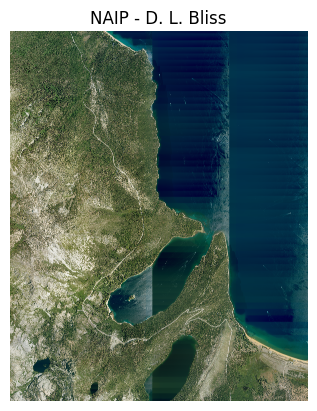

In [45]:
from pathlib import Path

with rasterio.open(dl_bliss_fp) as src:
    scale = 1
    preview = src.read(
        indexes=[1,2,3], 
        out_shape=(3, src.height // scale, src.width // scale),
        resampling=rasterio.enums.Resampling.bilinear
    ).astype(np.float32)

rgb = np.transpose(preview, (1,2,0))

plt.imshow(np.clip(rgb / (np.nanmax(rgb) + 1e-12), 0, 1))
plt.title("NAIP - D. L. Bliss")
plt.axis("off")
plt.show()